In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','notebook','grid'])

from datetime import datetime as dt

In [2]:
import importlib
from src import PhotonBoxPropagationSimulator as Simulator
from src import LinearAttenuationCoeff_load as LAC_loader
#LAC_loader?
#Simulator?

---
## Linear Attenuation Coefficients

At 0.01 MeV, total linear attenuation coefficient is 1424.8188 /cm; (mean free path = 0.0007 cm)
At 0.05 MeV, total linear attenuation coefficient is 83.7661 /cm; (mean free path = 0.0119 cm)
At 0.08 MeV, total linear attenuation coefficient is 23.9413 /cm; (mean free path = 0.0418 cm)
At 0.1 MeV, total linear attenuation coefficient is 60.5096 /cm; (mean free path = 0.0165 cm)
At 0.15 MeV, total linear attenuation coefficient is 21.6576 /cm; (mean free path = 0.0462 cm)
At 0.5 MeV, total linear attenuation coefficient is 1.7000 /cm; (mean free path = 0.5882 cm)
At 1.0 MeV, total linear attenuation coefficient is 0.7715 /cm; (mean free path = 1.2962 cm)
At 2.0 MeV, total linear attenuation coefficient is 0.5137 /cm; (mean free path = 1.9465 cm)


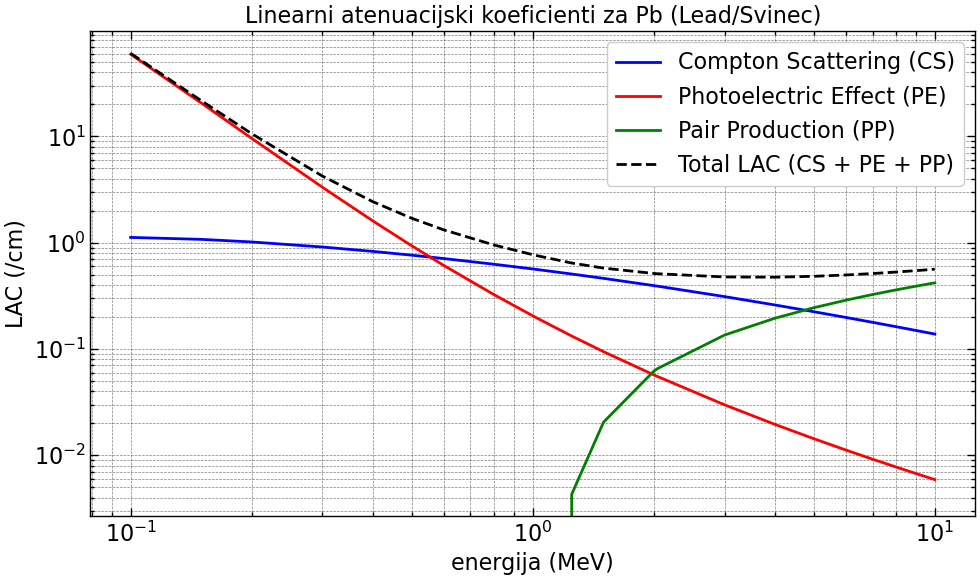

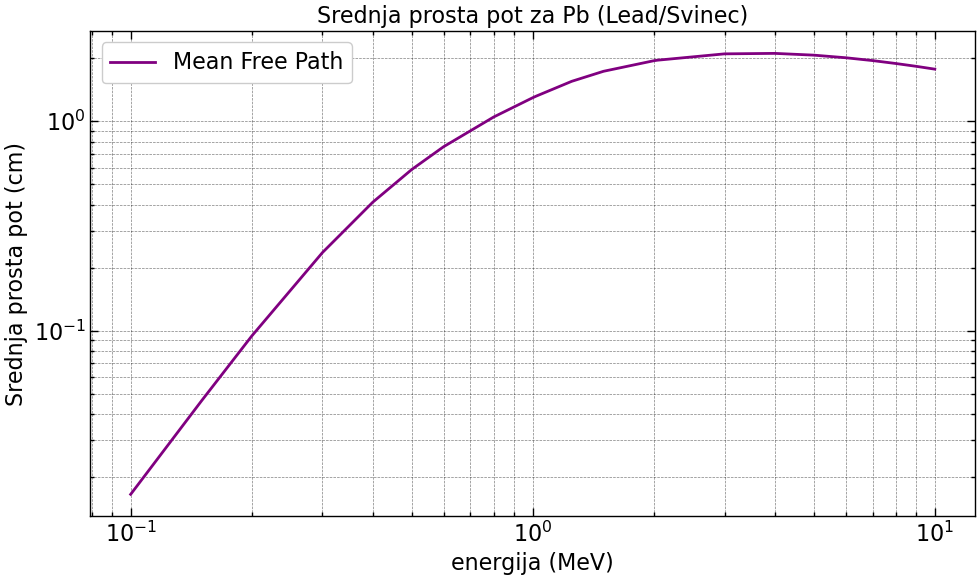

In [3]:
"""
Load a txt file with the data for the mac = mass attenuation coefficient of LEAD
Data is from NIST XCom database.
MAC is in units of cm^2/g
Columns:
 - Energy (MeV) [1kev - 10 MeV]
 - mac_coherent (Rayleigh scattering) [cm^2/g]
 - mac_incoherent (Compton scattering) [cm^2/g]
 - mac_photoelectric (Photoelectric effect) [cm^2/g]
 - mac_pair_production_nuclear (Pair production in nuclear field) [cm^2/g]
 - mac_pair_production_electron (Pair production in electron field) [cm^2/g]
 - mac_total (Total mass attenuation coefficient) [cm^2/g] - sum of all processes
 - mac_tot_w/o_coherent (Total mass attenuation coefficient without Rayleigh scattering) [cm^2/g]
"""

importlib.reload(LAC_loader)

path = "../mac_nistxcom/mac_lead.txt"
lead_density = 11.34  # g/cm^3
lead_lac_importer = LAC_loader.LACLoader(path, lead_density, material_name="Pb (Lead/Svinec)")
energy_lead, lac_pp_lead, lac_cs_lead, lac_pe_lead, lac_total_lead = lead_lac_importer.get_lac_data()

#* gather lac data for simulation
LAC_data_lead = {
    'energy': energy_lead,  # Energy values for the linear attenuation coefficients
    'lac_cs': lac_cs_lead,  # Linear attenuation coefficient for Compton scattering
    'lac_pe': lac_pe_lead,  # Linear attenuation coefficient for photoelectric effect
    'lac_pp': lac_pp_lead,  # Linear attenuation coefficient for pair production
}

energies = [0.01,0.05,0.08,0.1,0.15,0.5,1.0,2.0] # MeV

for energy in energies:
    lac_value = lead_lac_importer.get_lac_at_energy(energy)
    print(f"At {energy} MeV, total linear attenuation coefficient is {lac_value:.4f} /cm"
          f"; (mean free path = {1/lac_value:.4f} cm)"
          )
    
# plot
Emin = 0.1 # 0.05MeV - K line at 0.88keV
E_max = 10.0  # 100MeV - PP dominates, but lac_tot increases slowly with energy!
lead_lac_importer.plot(Emin, E_max)
lead_lac_importer.plot_mean_free_path(Emin, E_max)

In [4]:
 #* define energies of interest (low and middle energy range)
energies_low = [0.001,0.01,0.05,0.08,0.0875,0.089,0.1,0.15,0.2] # MeV
energies_middle = [0.3,0.4,0.511,0.55,0.7,0.85,1.0,1.5,2.0,3.0,5.0,10.0,100.0] # MeV

#* Low energies - rapid decrease in attenuation coefficient with energy, dominated by photoelectric effect
print(f"--- Linear Attenuation Coefficient and Mean Free Path in Lead (Pb) ---")
print(f"\n--- Low energy range [below 200keV] ---")
print(f"\t*From 1keV to 87.5keV: lac decreases rapidly from {lead_lac_importer.get_lac_at_energy(0.001):.4f} /cm to {lead_lac_importer.get_lac_at_energy(0.0875):.4f} /cm")
print(f"\t*L lines at 13keV and 15keV for lead (Pb)!! -> lac increases from {lead_lac_importer.get_lac_at_energy(0.0125):.4f} /cm to {lead_lac_importer.get_lac_at_energy(0.0175):.4f} /cm")
print(f"\t*K line at 88keV for lead (Pb)!! -> lac increases from {lead_lac_importer.get_lac_at_energy(0.0875):.4f} /cm to {lead_lac_importer.get_lac_at_energy(0.089):.4f} /cm")
print(f"\t*From 90keV to 200keV: lac decreases rapidly again from {lead_lac_importer.get_lac_at_energy(0.089):.4f} /cm to {lead_lac_importer.get_lac_at_energy(0.2):.4f} /cm")  
print(f"\t*Photoelectric effect dominates below 0.2MeV!")
print(f"From 0.2MeV to 0.3MeV: lac decreases more slowly from {lead_lac_importer.get_lac_at_energy(0.2):.4f} /cm to {lead_lac_importer.get_lac_at_energy(0.3):.4f} /cm")
for energy in energies_low:
    lac_value = lead_lac_importer.get_lac_at_energy(energy)
    print(f"At {energy} MeV, lac_tot  = {lac_value:.4f} /cm"
          f"; (mean free path = {1/lac_value:.4f} cm)"
          )
    


#* Middle energies - gradual decrease in attenuation coefficient with energy, dominated by Compton scattering
print(f"\n--- Middle energy range [range: 0.2Mev - 100MeV] ---")
print(f"\t*From 300keV to 800keV: lac decreases from {lead_lac_importer.get_lac_at_energy(0.3):.4f} /cm to {lead_lac_importer.get_lac_at_energy(0.8):.4f} /cm")
print(f"\tlac changes SLOWLY between 800keV and 100MeV (max~1/cm - at 0.8MeV and 100MeV; min~0.5/cm - at cca 3MeV)")
print(f"\t*Compton dominates between 0.55MeV and 4.5MeV - below: PE, above: PP")
print(f"\t*At 0.511MeV - annihilation line! - lac ~ 1.66/cm, mean free path ~ 0.60 cm")
for energy in energies_middle:
    lac_value = lead_lac_importer.get_lac_at_energy(energy)
    print(f"At {energy} MeV, lac_tot  = {lac_value:.4f} /cm"
          f"; (mean free path = {1/lac_value:.4f} cm)"
          )

--- Linear Attenuation Coefficient and Mean Free Path in Lead (Pb) ---

--- Low energy range [below 200keV] ---
	*From 1keV to 87.5keV: lac decreases rapidly from 58934.0207 /cm to 18.9983 /cm
	*L lines at 13keV and 15keV for lead (Pb)!! -> lac increases from 842.0487 /cm to 1416.7514 /cm
	*K line at 88keV for lead (Pb)!! -> lac increases from 18.9983 /cm to 82.1763 /cm
	*From 90keV to 200keV: lac decreases rapidly again from 82.1763 /cm to 10.6149 /cm
	*Photoelectric effect dominates below 0.2MeV!
From 0.2MeV to 0.3MeV: lac decreases more slowly from 10.6149 /cm to 4.2339 /cm
At 0.001 MeV, lac_tot  = 58934.0207 /cm; (mean free path = 0.0000 cm)
At 0.01 MeV, lac_tot  = 1424.8188 /cm; (mean free path = 0.0007 cm)
At 0.05 MeV, lac_tot  = 83.7661 /cm; (mean free path = 0.0119 cm)
At 0.08 MeV, lac_tot  = 23.9413 /cm; (mean free path = 0.0418 cm)
At 0.0875 MeV, lac_tot  = 18.9983 /cm; (mean free path = 0.0526 cm)
At 0.089 MeV, lac_tot  = 82.1763 /cm; (mean free path = 0.0122 cm)
At 0.1 MeV,

In [5]:
# Reuse existing variables from notebook:
# - lead_lac_importer
# - energies_low
# - energies_middle

def print_lac_table(title, energies_list):
    print(f"\n{title}")
    print("-" * len(title))
    print(f"{'Energy [MeV]':>12} | {'LAC_tot [1/cm]':>14} | {'Mean free path [cm]':>19}")
    print("-" * 52)
    for E in energies_list:
        lac = lead_lac_importer.get_lac_at_energy(E)
        mfp = 1.0 / lac
        print(f"{E:12.4f} | {lac:14.4f} | {mfp:19.4f}")
    print("-" * 52)

# Headline summary
print("--- Linear Attenuation Coefficient and Mean Free Path in Lead (Pb) ---")

# Key physical observations (concise + readable)
print("\nLow-energy behavior [0.001–0.2 MeV]:")
print(f"• 1 keV  -> 87.5 keV: strong drop in LAC ({lead_lac_importer.get_lac_at_energy(0.001):.2f} -> {lead_lac_importer.get_lac_at_energy(0.0875):.2f} /cm)")
print(f"• L-edges (~13–15 keV): rise ({lead_lac_importer.get_lac_at_energy(0.0125):.2f} -> {lead_lac_importer.get_lac_at_energy(0.0175):.2f} /cm)")
print(f"• K-edge (~88 keV): rise ({lead_lac_importer.get_lac_at_energy(0.0875):.2f} -> {lead_lac_importer.get_lac_at_energy(0.089):.2f} /cm)")
print("• Photoelectric effect dominates below 0.2 MeV (and up to ~ 550keV)")

print("\nMiddle-energy behavior [0.3–100 MeV]:")
print(f"• 0.3 -> 0.7 MeV: LAC decreases ({lead_lac_importer.get_lac_at_energy(0.3):.3f} -> {lead_lac_importer.get_lac_at_energy(0.7):.3f} /cm)")
print(f"• 0.7 -> 100 MeV: LAC changes slowly (max ~ {lead_lac_importer.get_lac_at_energy(0.7):.3f} /cm at 0.8 MeV, min ~ {lead_lac_importer.get_lac_at_energy(3.0):.3f} /cm at cca 3 MeV, then increases again to ~ {lead_lac_importer.get_lac_at_energy(100.0):.3f} /cm at 100 MeV)")
print("• Compton region ~0.55 to ~4.5 MeV")
print(f"• 0.511 MeV (annihilation): LAC = {lead_lac_importer.get_lac_at_energy(0.511):.3f} /cm, MFP = {1/lead_lac_importer.get_lac_at_energy(0.511):.3f} cm")

# Tables
print_lac_table("Low energy range [0.001–0.2 MeV]", energies_low)
print_lac_table("Middle energy range [0.3–100 MeV]", energies_middle)

--- Linear Attenuation Coefficient and Mean Free Path in Lead (Pb) ---

Low-energy behavior [0.001–0.2 MeV]:
• 1 keV  -> 87.5 keV: strong drop in LAC (58934.02 -> 19.00 /cm)
• L-edges (~13–15 keV): rise (842.05 -> 1416.75 /cm)
• K-edge (~88 keV): rise (19.00 -> 82.18 /cm)
• Photoelectric effect dominates below 0.2 MeV (and up to ~ 550keV)

Middle-energy behavior [0.3–100 MeV]:
• 0.3 -> 0.7 MeV: LAC decreases (4.234 -> 1.138 /cm)
• 0.7 -> 100 MeV: LAC changes slowly (max ~ 1.138 /cm at 0.8 MeV, min ~ 0.476 /cm at cca 3 MeV, then increases again to ~ 1.056 /cm at 100 MeV)
• Compton region ~0.55 to ~4.5 MeV
• 0.511 MeV (annihilation): LAC = 1.659 /cm, MFP = 0.603 cm

Low energy range [0.001–0.2 MeV]
--------------------------------
Energy [MeV] | LAC_tot [1/cm] | Mean free path [cm]
----------------------------------------------------
      0.0010 |     58934.0207 |              0.0000
      0.0100 |      1424.8188 |              0.0007
      0.0500 |        83.7661 |              0.0119


---
## lac_pe / lac_cs ratio over energies

In [9]:
pe_cs_ratio = lac_pe_lead / lac_cs_lead

In [16]:
E = 0.089 # MeV
ratio = np.interp(E, energy_lead, pe_cs_ratio)
print(f"Ratio of photoelectric to Compton LAC at {E} MeV: {ratio:.5f}")

Ratio of photoelectric to Compton LAC at 0.089 MeV: 72.00678


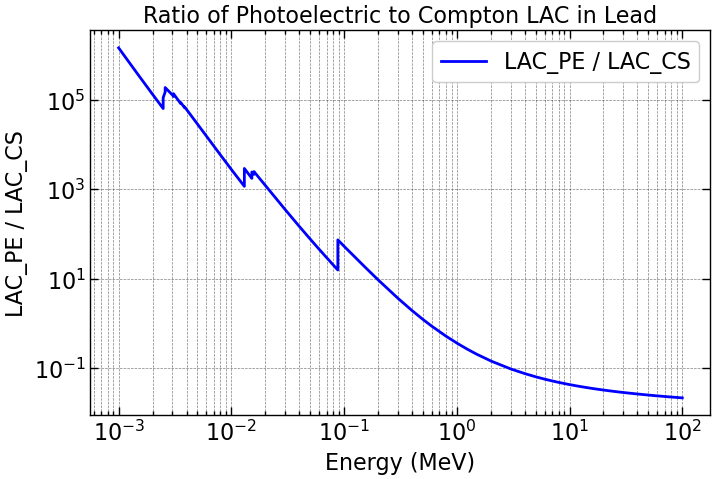

In [18]:
# plot pe_cs_rati(E)
E_min_plot = 0.01 # MeV
E_max_plot = 10.0 # MeV

#ratio_data = np.interp(np.logspace(np.log10(E_min_plot), np.log10(E_max_plot), 100), energy_lead, pe_cs_ratio)

plt.figure(figsize=(8, 5))
plt.plot(lead_lac_importer.energy, pe_cs_ratio, label='LAC_PE / LAC_CS', color='blue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (MeV)')
plt.ylabel('LAC_PE / LAC_CS')
plt.title('Ratio of Photoelectric to Compton LAC in Lead')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()

